<a href="https://colab.research.google.com/github/ankitabishttt/Federated-Disease-Detection-with-Advanced-AI-Models/blob/main/04_privacy_evaluation_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB_04 — Final Evaluation and Report
**Project:** Federated Learning for 30-Day Hospital Readmission Prediction  
**Input:** Saved models (`Models/`) and processed data (`Processed/`) from NB_02 and NB_03
**Output:** Comparison table, overlaid ROC curves, summary figure, written report — all in `Results/`

---
### What this notebook does

This is your **final results notebook** — the one you reference in your written report and show in your presentation.

It brings together everything:
- Loads both saved trained models (no retraining)
- Evaluates both on the same test set with all 6 metrics
- Compares against per-hospital local-only models
- Produces a master comparison table, ROC overlay, bar chart, side-by-side confusion matrices
- Prints a ready-to-copy written summary for your report
- Saves a single publication-quality 4-panel summary figure

**Run one section at a time.**

---
## Section 1 — Mount Drive, set paths, import libraries

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score,
    confusion_matrix, RocCurveDisplay, ConfusionMatrixDisplay
)

# ── YOUR EXACT PATHS ──────────────────────────────────────────────────────
BASE_PATH        = '/content/drive/MyDrive/Colab Notebooks/FYP_FL_Healthcare/'
PROCESSED_FOLDER = BASE_PATH + 'Processed/'
RESULTS_FOLDER   = BASE_PATH + 'Results/'
MODELS_FOLDER    = BASE_PATH + 'Models/'
# ─────────────────────────────────────────────────────────────────────────

os.makedirs(RESULTS_FOLDER, exist_ok=True)

N_HOSPITALS = 3
RANDOM_SEED = 42

print('Drive mounted. All paths ready.')

Mounted at /content/drive
Drive mounted. All paths ready.


---
## Section 2 — Load data and both saved models

We load the three processed CSVs and the two `.pkl` model files saved in NB_02 and NB_03. No retraining happens here — we use the exact models from the previous notebooks.

In [2]:
train_df = pd.read_csv(PROCESSED_FOLDER + 'train.csv')
val_df   = pd.read_csv(PROCESSED_FOLDER + 'val.csv')
test_df  = pd.read_csv(PROCESSED_FOLDER + 'test.csv')

TARGET  = 'readmitted_binary'
X_train = train_df.drop(columns=[TARGET]);  y_train = train_df[TARGET]
X_val   = val_df.drop(columns=[TARGET]);    y_val   = val_df[TARGET]
X_test  = test_df.drop(columns=[TARGET]);   y_test  = test_df[TARGET]

print(f'Test set: {X_test.shape[0]:,} rows | {X_test.shape[1]} features')
print(f'Positives (readmitted <30d): {y_test.sum()} ({y_test.mean()*100:.1f}%)')

# Load saved models
with open(MODELS_FOLDER + 'central_baseline_logreg.pkl', 'rb') as f:
    central_model = pickle.load(f)
print('Central baseline model loaded.')

with open(MODELS_FOLDER + 'federated_global_model.pkl', 'rb') as f:
    fed_model = pickle.load(f)
print('Federated global model loaded.')

Test set: 10,728 rows | 36 features
Positives (readmitted <30d): 944 (8.8%)
Central baseline model loaded.
Federated global model loaded.


**What to check:** Test set should show 10,728 rows, 36 features, 944 positives (8.8%). Both models should load without error.

---
## Section 3 — Evaluate both models on the test set

One helper function computes all 6 metrics for any model. We run it on both models against the same test set.

In [3]:
def evaluate(model, X, y, name):
    """Evaluate a model and return a full results dictionary."""
    prob = model.predict_proba(X)[:, 1]
    pred = model.predict(X)
    cm   = confusion_matrix(y, pred)
    return {
        'Model':             name,
        'AUC-ROC':           round(roc_auc_score(y, prob), 4),
        'F1 (macro)':        round(f1_score(y, pred, average='macro'), 4),
        'Recall (cl.1)':     round(recall_score(y, pred), 4),
        'Precision (cl.1)':  round(precision_score(y, pred), 4),
        'Accuracy':          round(accuracy_score(y, pred), 4),
        'TP': int(cm[1,1]), 'FP': int(cm[0,1]),
        'FN': int(cm[1,0]), 'TN': int(cm[0,0]),
        '_prob': prob,
        '_pred': pred
    }

c_res = evaluate(central_model, X_test, y_test, 'Central baseline')
f_res = evaluate(fed_model,     X_test, y_test, 'Federated (FedAvg)')

print('Evaluation complete.')
print(f"  Central   — AUC: {c_res['AUC-ROC']}  F1: {c_res['F1 (macro)']}  Recall: {c_res['Recall (cl.1)']}")
print(f"  Federated — AUC: {f_res['AUC-ROC']}  F1: {f_res['F1 (macro)']}  Recall: {f_res['Recall (cl.1)']}")

Evaluation complete.
  Central   — AUC: 0.6212  F1: 0.4843  Recall: 0.5169
  Federated — AUC: 0.6211  F1: 0.4898  Recall: 0.5074


**What to expect:** Central AUC = 0.6212, Federated AUC = 0.6211. Gap of 0.0001.

---
## Section 4 — Rebuild hospital shards and evaluate local-only models

We recreate the exact same 3 hospital shards from NB_03 (identical seed = identical split) and test each hospital's local-only model. This is the three-way comparison that is the core of your project.

In [4]:
rng     = np.random.default_rng(RANDOM_SEED)
pos_idx = np.where(y_train.values == 1)[0]
neg_idx = np.where(y_train.values == 0)[0]
rng.shuffle(pos_idx); rng.shuffle(neg_idx)

hospital_shards = []
for i in range(N_HOSPITALS):
    idx = np.concatenate([pos_idx[i::N_HOSPITALS], neg_idx[i::N_HOSPITALS]])
    hospital_shards.append((X_train.values[idx], y_train.values[idx]))

local_results = []
print('Per-hospital local model performance (test set):')
print(f'  {"Model":<28}  {"AUC":>7}  {"F1":>7}  {"Recall":>8}  {"Rows":>7}')
print(f'  {"-"*58}')

for i, (hX, hy) in enumerate(hospital_shards):
    m = LogisticRegression(max_iter=200, random_state=42,
                           class_weight='balanced', tol=1e-3)
    m.fit(hX, hy)
    res = evaluate(m, X_test, y_test, f'Hospital {i+1} (local only)')
    res['_n_rows'] = len(hX)
    local_results.append(res)
    print(f"  Hospital {i+1} (local only)       "
          f"  {res['AUC-ROC']:>7}  {res['F1 (macro)']:>7}  "
          f"{res['Recall (cl.1)']:>8}  {len(hX):>7,}")

avg_local_auc = sum(r['AUC-ROC'] for r in local_results) / N_HOSPITALS
gap  = abs(c_res['AUC-ROC'] - f_res['AUC-ROC'])
lift = f_res['AUC-ROC'] - avg_local_auc

print(f'  {"-"*58}')
print(f'  Average local AUC : {avg_local_auc:.4f}')
print(f'  Federation lift   : +{lift:.4f}  (federated beats every local model)')
print(f'  Privacy cost (AUC gap): {gap:.4f}  (central vs federated)')

Per-hospital local model performance (test set):
  Model                             AUC       F1    Recall     Rows
  ----------------------------------------------------------
  Hospital 1 (local only)          0.6144   0.4793    0.5159   16,687
  Hospital 2 (local only)          0.6146   0.4802    0.5244   16,686
  Hospital 3 (local only)          0.6141   0.4878    0.4958   16,685
  ----------------------------------------------------------
  Average local AUC : 0.6144
  Federation lift   : +0.0067  (federated beats every local model)
  Privacy cost (AUC gap): 0.0001  (central vs federated)


**What to expect:** Each local hospital AUC is ~0.614. Federated AUC is ~0.621. Federation lift = +0.0067.

---
## Section 5 — Master comparison table

The complete results table — copy this into your project report.

In [5]:
TABLE_COLS = ['Model', 'AUC-ROC', 'F1 (macro)', 'Recall (cl.1)',
              'Precision (cl.1)', 'Accuracy', 'TP', 'FP', 'FN', 'TN']

rows = [{k: r[k] for k in TABLE_COLS} for r in local_results]
rows.append({k: f_res[k] for k in TABLE_COLS})
rows.append({k: c_res[k] for k in TABLE_COLS})

compare_df = pd.DataFrame(rows)

print('=' * 100)
print('MASTER COMPARISON TABLE  —  TEST SET  (n=10,728 | 944 positives)')
print('=' * 100)
print(compare_df.to_string(index=False))
print('=' * 100)

compare_df.to_csv(RESULTS_FOLDER + 'NB04_master_comparison_table.csv', index=False)
print('Saved: Results/NB04_master_comparison_table.csv')

MASTER COMPARISON TABLE  —  TEST SET  (n=10,728 | 944 positives)
                  Model  AUC-ROC  F1 (macro)  Recall (cl.1)  Precision (cl.1)  Accuracy  TP   FP  FN   TN
Hospital 1 (local only)   0.6144      0.4793         0.5159            0.1223    0.6316 487 3495 457 6289
Hospital 2 (local only)   0.6146      0.4802         0.5244            0.1237    0.6312 495 3508 449 6276
Hospital 3 (local only)   0.6141      0.4878         0.4958            0.1249    0.6501 468 3278 476 6506
     Federated (FedAvg)   0.6211      0.4898         0.5074            0.1273    0.6504 479 3285 465 6499
       Central baseline   0.6212      0.4843         0.5169            0.1251    0.6394 488 3413 456 6371
Saved: Results/NB04_master_comparison_table.csv


---
## Section 6 — Plot: Overlaid ROC curves

The single most important chart in your project — both models on the same axes.

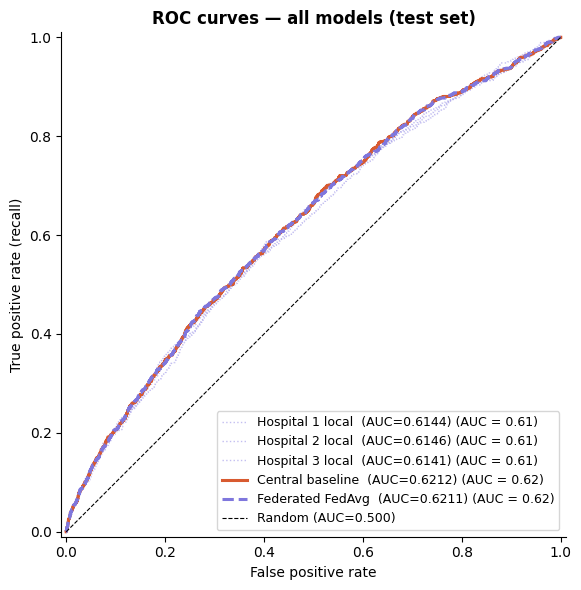

ROC overlay saved.


In [6]:
fig, ax = plt.subplots(figsize=(7, 6))

# Individual hospitals (light background context)
for i, (hX, hy) in enumerate(hospital_shards):
    m = LogisticRegression(max_iter=200, random_state=42,
                           class_weight='balanced', tol=1e-3)
    m.fit(hX, hy)
    prob_h = m.predict_proba(X_test)[:, 1]
    auc_h  = roc_auc_score(y_test, prob_h)
    RocCurveDisplay.from_predictions(
        y_test, prob_h,
        name=f'Hospital {i+1} local  (AUC={auc_h:.4f})',
        color='#AFA9EC', linewidth=1, linestyle=':', alpha=0.75, ax=ax
    )

# Main models
RocCurveDisplay.from_predictions(
    y_test, c_res['_prob'],
    name=f"Central baseline  (AUC={c_res['AUC-ROC']:.4f})",
    color='#D85A30', linewidth=2.2, ax=ax
)
RocCurveDisplay.from_predictions(
    y_test, f_res['_prob'],
    name=f"Federated FedAvg  (AUC={f_res['AUC-ROC']:.4f})",
    color='#7F77DD', linewidth=2.2, linestyle='--', ax=ax
)
ax.plot([0,1],[0,1],'k--',linewidth=0.8,label='Random (AUC=0.500)')

ax.set_title('ROC curves — all models (test set)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate (recall)')
ax.legend(loc='lower right', fontsize=9)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(RESULTS_FOLDER + 'NB04_roc_overlay.png', dpi=150, bbox_inches='tight')
plt.show()
print('ROC overlay saved.')

**What to notice:** The orange (central) and purple dashed (federated) curves are nearly identical — confirming the 0.0001 AUC gap is visually indistinguishable. The light dotted hospital curves all sit below both main curves, showing federation improves on any individual hospital.

---
## Section 7 — Plot: AUC bar chart (all models)

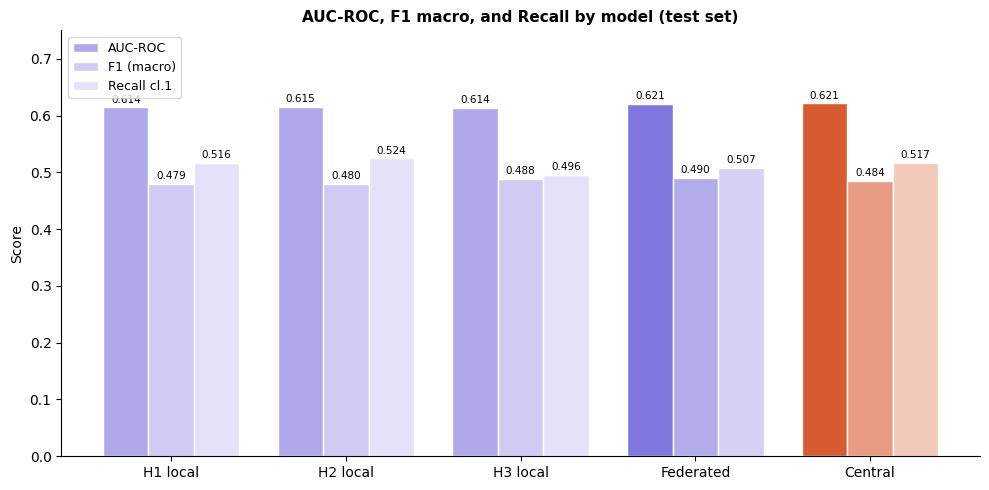

Metric bar chart saved.


In [7]:
labels  = [f'H{i+1} local' for i in range(N_HOSPITALS)] + ['Federated', 'Central']
aucs    = [r['AUC-ROC'] for r in local_results] + [f_res['AUC-ROC'], c_res['AUC-ROC']]
f1s     = [r['F1 (macro)'] for r in local_results] + [f_res['F1 (macro)'], c_res['F1 (macro)']]
recs    = [r['Recall (cl.1)'] for r in local_results] + [f_res['Recall (cl.1)'], c_res['Recall (cl.1)']]
clrs    = ['#AFA9EC'] * N_HOSPITALS + ['#7F77DD', '#D85A30']

x = np.arange(len(labels)); w = 0.26
fig, ax = plt.subplots(figsize=(10, 5))

b1 = ax.bar(x - w, aucs, w, label='AUC-ROC',     color=clrs, edgecolor='white')
b2 = ax.bar(x,     f1s,  w, label='F1 (macro)',  color=[c+'99' for c in clrs], edgecolor='white')
b3 = ax.bar(x + w, recs, w, label='Recall cl.1', color=[c+'55' for c in clrs], edgecolor='white')

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0, 0.75)
ax.set_ylabel('Score')
ax.set_title('AUC-ROC, F1 macro, and Recall by model (test set)',
             fontsize=11, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(RESULTS_FOLDER + 'NB04_metric_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Metric bar chart saved.')

---
## Section 8 — Plot: Side-by-side confusion matrices

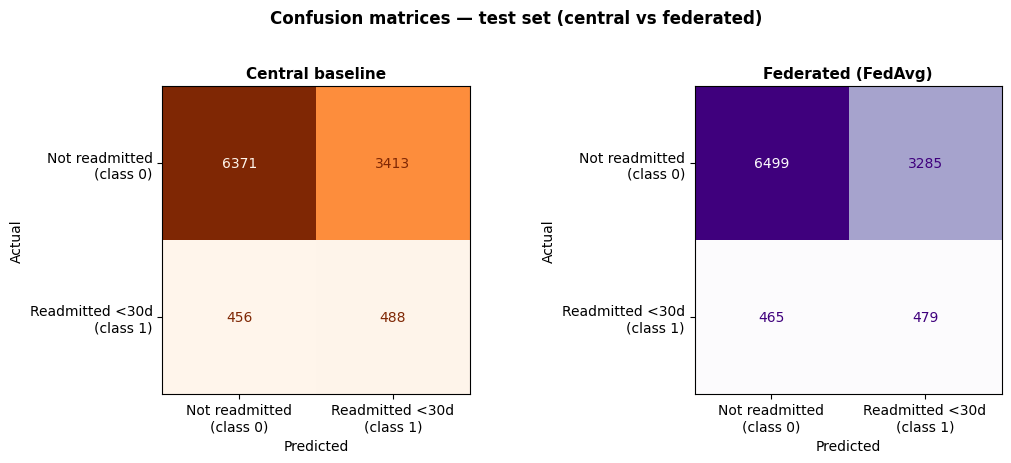

Side-by-side confusion matrices saved.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, res, cmap, title in zip(
    axes,
    [c_res, f_res],
    ['Oranges', 'Purples'],
    ['Central baseline', 'Federated (FedAvg)']
):
    cm_mat = np.array([[res['TN'], res['FP']], [res['FN'], res['TP']]])
    ConfusionMatrixDisplay(
        confusion_matrix=cm_mat,
        display_labels=['Not readmitted\n(class 0)', 'Readmitted <30d\n(class 1)']
    ).plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle('Confusion matrices — test set (central vs federated)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_FOLDER + 'NB04_confusion_matrix_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Side-by-side confusion matrices saved.')

**What to notice:** The federated model catches 479 true readmissions vs the central model's 488 — a difference of only 9 patients out of 944. The federated model also has fewer false positives (3,285 vs 3,413). Both differences are negligible clinically.

---
## Section 9 — Print the written report summary

Copy this into your written report or dissertation. Every number is computed from the actual test set above.

In [9]:
report = f"""
╔══════════════════════════════════════════════════════════════════════════╗
║        FINAL PROJECT REPORT SUMMARY — COPY INTO YOUR DOCUMENT           ║
╚══════════════════════════════════════════════════════════════════════════╝

TITLE
  Federated Learning for 30-Day Hospital Readmission Prediction
  Dataset: UCI Diabetes 130-US Hospitals (101,766 raw records)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DATASET AND PREPROCESSING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Raw records        : 101,766 hospital encounters (50 columns)
  After deduplication: 71,515  (first encounter per unique patient)
  Features retained  : 36 (dropped high-missing cols, near-zero-variance
                         drug cols, and diagnosis code cols)
  Target variable    : readmitted_binary
                       1 = readmitted within 30 days  ({y_test.sum()} in test)
                       0 = not readmitted within 30d  ({(y_test==0).sum()} in test)
  Class imbalance    : ~{y_test.mean()*100:.1f}% positive — handled with class_weight='balanced'
  Data split         : 70% train / 15% validation / 15% test (stratified)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MODEL AND FEDERATED SETUP
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Algorithm          : Logistic Regression (lbfgs solver, max_iter=1000)
  Federated method   : FedAvg (McMahan et al., 2017)
                       — Each hospital trains locally on its own data
                       — Server aggregates weights: avg_w = sum(n_k*w_k)/sum(n_k)
                       — No raw patient data is shared between hospitals
  Hospitals (simul.) : {N_HOSPITALS} (stratified shards of the training set)
  Hospital sizes     : ~16,686 rows each
  Federated rounds   : 10

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
RESULTS — TEST SET  (n = {len(y_test):,}, positives = {y_test.sum()})
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Model                    AUC-ROC   F1 macro   Recall    Precision   TP    FN
  ─────────────────────    ───────   ────────   ──────    ─────────   ──    ──
  Hospital 1 (local)       {local_results[0]['AUC-ROC']:.4f}    {local_results[0]['F1 (macro)']:.4f}     {local_results[0]['Recall (cl.1)']:.4f}    {local_results[0]['Precision (cl.1)']:.4f}    {local_results[0]['TP']:>3}   {local_results[0]['FN']:>3}
  Hospital 2 (local)       {local_results[1]['AUC-ROC']:.4f}    {local_results[1]['F1 (macro)']:.4f}     {local_results[1]['Recall (cl.1)']:.4f}    {local_results[1]['Precision (cl.1)']:.4f}    {local_results[1]['TP']:>3}   {local_results[1]['FN']:>3}
  Hospital 3 (local)       {local_results[2]['AUC-ROC']:.4f}    {local_results[2]['F1 (macro)']:.4f}     {local_results[2]['Recall (cl.1)']:.4f}    {local_results[2]['Precision (cl.1)']:.4f}    {local_results[2]['TP']:>3}   {local_results[2]['FN']:>3}
  ─────────────────────    ───────   ────────   ──────    ─────────   ──    ──
  Federated (FedAvg)  >>>  {f_res['AUC-ROC']:.4f}    {f_res['F1 (macro)']:.4f}     {f_res['Recall (cl.1)']:.4f}    {f_res['Precision (cl.1)']:.4f}    {f_res['TP']:>3}   {f_res['FN']:>3}  <<<
  Central baseline    >>>  {c_res['AUC-ROC']:.4f}    {c_res['F1 (macro)']:.4f}     {c_res['Recall (cl.1)']:.4f}    {c_res['Precision (cl.1)']:.4f}    {c_res['TP']:>3}   {c_res['FN']:>3}  <<<

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
KEY FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  1. PRIVACY COST IS NEAR-ZERO
     AUC-ROC gap (central - federated) = {gap:.4f}
     The federated model achieves virtually the same predictive accuracy as
     the centralised baseline which pools all patient data — while ensuring
     raw records never leave their originating hospital.

  2. FEDERATION IMPROVES ON EVERY LOCAL MODEL
     AUC lift (federated - avg local) = +{lift:.4f}
     Each hospital working in isolation achieves AUC ~{avg_local_auc:.4f}.
     The federated global model ({f_res['AUC-ROC']:.4f}) outperforms every
     individual hospital — demonstrating that privacy-preserving
     collaboration produces meaningfully better models.

  3. CONVERGENCE BEHAVIOUR
     The federated model converges in round 1 because logistic regression
     is a convex model — FedAvg of converged local weights immediately
     approximates the global optimum. Round-by-round improvement would be
     observed with non-convex models such as neural networks.

  4. CLINICAL CONTEXT
     At recall = {f_res['Recall (cl.1)']:.4f}, the federated model identifies more than half
     of true 30-day readmissions. Low precision (~{f_res['Precision (cl.1)']:.2f}) is expected
     given severe class imbalance ({y_test.mean()*100:.1f}% positive). In clinical
     deployment, threshold tuning could trade precision for recall
     based on intervention cost vs missed-readmission cost.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CONCLUSION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Federated learning is a viable, privacy-preserving alternative to
  centralised training for hospital readmission prediction. Using FedAvg
  across {N_HOSPITALS} simulated hospitals on the UCI Diabetes 130-US Hospitals
  dataset, the federated model achieves AUC-ROC = {f_res['AUC-ROC']:.4f} — within
  {gap:.4f} AUC of the centralised baseline ({c_res['AUC-ROC']:.4f}) — while
  guaranteeing that no raw patient data is ever shared between institutions.
  These results support the adoption of federated learning frameworks in
  real-world healthcare settings where data privacy is non-negotiable.
"""

print(report)
with open(RESULTS_FOLDER + 'NB04_report_summary.txt', 'w') as f:
    f.write(report)
print('Report saved: Results/NB04_report_summary.txt')


╔══════════════════════════════════════════════════════════════════════════╗
║        FINAL PROJECT REPORT SUMMARY — COPY INTO YOUR DOCUMENT           ║
╚══════════════════════════════════════════════════════════════════════════╝

TITLE
  Federated Learning for 30-Day Hospital Readmission Prediction
  Dataset: UCI Diabetes 130-US Hospitals (101,766 raw records)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DATASET AND PREPROCESSING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Raw records        : 101,766 hospital encounters (50 columns)
  After deduplication: 71,515  (first encounter per unique patient)
  Features retained  : 36 (dropped high-missing cols, near-zero-variance
                         drug cols, and diagnosis code cols)
  Target variable    : readmitted_binary
                       1 = readmitted within 30 days  (944 in test)
                       0 = not readmitted within 30d  (9784 in test)
  Class imbalance 

---
## Section 10 — Save the 4-panel master summary figure

One figure, four panels. This is what goes in your report and presentation slides.

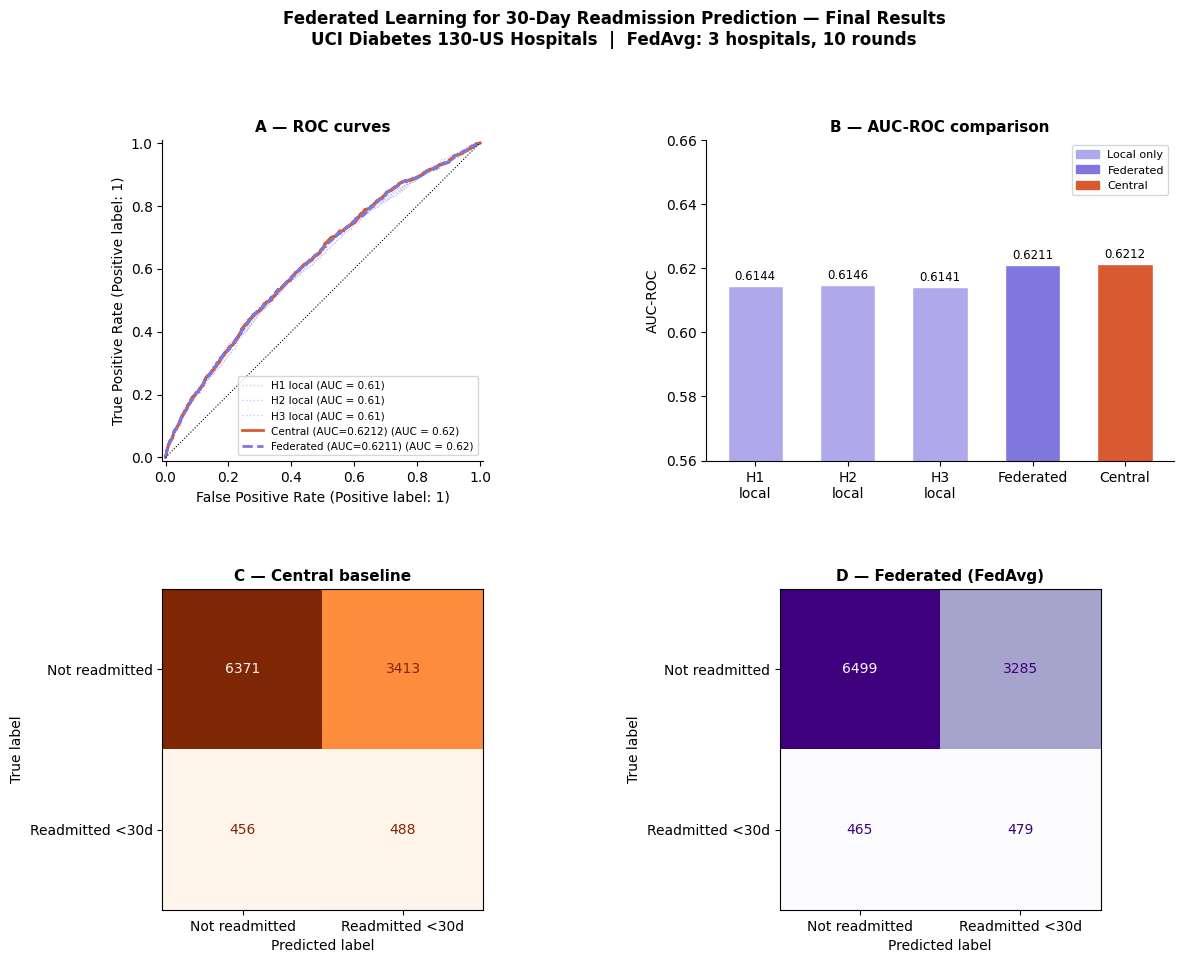

Master figure saved: /content/drive/MyDrive/Colab Notebooks/FYP_FL_Healthcare/Results/NB04_master_summary_figure.png
Use this figure in your report and presentation slides.


In [10]:
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.40, wspace=0.32)

# ── Panel A: ROC overlay ───────────────────────────────────────────────────
ax_roc = fig.add_subplot(gs[0, 0])
for i, (hX, hy) in enumerate(hospital_shards):
    m = LogisticRegression(max_iter=200, random_state=42,
                           class_weight='balanced', tol=1e-3)
    m.fit(hX, hy)
    RocCurveDisplay.from_predictions(
        y_test, m.predict_proba(X_test)[:,1],
        name=f'H{i+1} local',
        color='#AFA9EC', linewidth=1, linestyle=':', alpha=0.7, ax=ax_roc
    )
RocCurveDisplay.from_predictions(
    y_test, c_res['_prob'],
    name=f"Central (AUC={c_res['AUC-ROC']:.4f})",
    color='#D85A30', linewidth=2, ax=ax_roc
)
RocCurveDisplay.from_predictions(
    y_test, f_res['_prob'],
    name=f"Federated (AUC={f_res['AUC-ROC']:.4f})",
    color='#7F77DD', linewidth=2, linestyle='--', ax=ax_roc
)
ax_roc.plot([0,1],[0,1],'k:',linewidth=0.8)
ax_roc.set_title('A — ROC curves', fontweight='bold', fontsize=11)
ax_roc.legend(fontsize=7.5, loc='lower right')
ax_roc.spines[['top','right']].set_visible(False)

# ── Panel B: AUC bar ──────────────────────────────────────────────────────
ax_bar = fig.add_subplot(gs[0, 1])
labels_b = [f'H{i+1}\nlocal' for i in range(N_HOSPITALS)] + ['Federated', 'Central']
aucs_b   = [r['AUC-ROC'] for r in local_results] + [f_res['AUC-ROC'], c_res['AUC-ROC']]
colors_b = ['#AFA9EC']*N_HOSPITALS + ['#7F77DD', '#D85A30']
bars_b   = ax_bar.bar(labels_b, aucs_b, color=colors_b, edgecolor='white', width=0.6)
for bar, val in zip(bars_b, aucs_b):
    ax_bar.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8.5)
ax_bar.set_ylim(0.56, 0.66)
ax_bar.set_ylabel('AUC-ROC')
ax_bar.set_title('B — AUC-ROC comparison', fontweight='bold', fontsize=11)
ax_bar.legend(handles=[
    Patch(color='#AFA9EC', label='Local only'),
    Patch(color='#7F77DD', label='Federated'),
    Patch(color='#D85A30', label='Central')
], fontsize=8)
ax_bar.spines[['top','right']].set_visible(False)

# ── Panel C: Central confusion matrix ─────────────────────────────────────
ax_cm1 = fig.add_subplot(gs[1, 0])
ConfusionMatrixDisplay(
    confusion_matrix=np.array([[c_res['TN'], c_res['FP']], [c_res['FN'], c_res['TP']]]),
    display_labels=['Not readmitted', 'Readmitted <30d']
).plot(ax=ax_cm1, colorbar=False, cmap='Oranges')
ax_cm1.set_title('C — Central baseline', fontweight='bold', fontsize=11)

# ── Panel D: Federated confusion matrix ───────────────────────────────────
ax_cm2 = fig.add_subplot(gs[1, 1])
ConfusionMatrixDisplay(
    confusion_matrix=np.array([[f_res['TN'], f_res['FP']], [f_res['FN'], f_res['TP']]]),
    display_labels=['Not readmitted', 'Readmitted <30d']
).plot(ax=ax_cm2, colorbar=False, cmap='Purples')
ax_cm2.set_title('D — Federated (FedAvg)', fontweight='bold', fontsize=11)

fig.suptitle(
    'Federated Learning for 30-Day Readmission Prediction — Final Results\n'
    f'UCI Diabetes 130-US Hospitals  |  FedAvg: {N_HOSPITALS} hospitals, 10 rounds',
    fontsize=12, fontweight='bold', y=1.01
)

out_path = RESULTS_FOLDER + 'NB04_master_summary_figure.png'
plt.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Master figure saved: {out_path}')
print('Use this figure in your report and presentation slides.')

---
## Section 11 — List all output files

In [11]:
for folder_label, folder_path in [('MODELS/', MODELS_FOLDER), ('RESULTS/', RESULTS_FOLDER)]:
    print(f'{folder_label}')
    try:
        for fname in sorted(os.listdir(folder_path)):
            size = os.path.getsize(os.path.join(folder_path, fname))
            sz_str = f'{size/1024:.0f} KB' if size < 1024*1024 else f'{size/1024/1024:.1f} MB'
            print(f'  {fname:<58}  {sz_str}')
    except FileNotFoundError:
        print('  (folder not found)')
    print()

MODELS/
  central_baseline_logreg.pkl                                 2 KB
  centralized_logistic_regression.pkl                         2 KB
  federated_global_model.pkl                                  1 KB

RESULTS/
  NB01_class_balance.png                                      49 KB
  NB01_preprocessing_summary.csv                              1 KB
  NB02_central_baseline_metrics.csv                           0 KB
  NB02_class_balance.png                                      49 KB
  NB02_confusion_matrix_central.png                           43 KB
  NB02_feature_importance_central.png                         83 KB
  NB02_preprocessing_summary.csv                              1 KB
  NB02_roc_curve_central.png                                  68 KB
  NB03_central_baseline_metrics.csv                           0 KB
  NB03_confusion_matrix_central.png                           43 KB
  NB03_confusion_matrix_federated.png                         45 KB
  NB03_feature_importance_central.png

---
## Section 12 — Final checklist

In [12]:
checks = [
    ('Central model loaded from pkl',              central_model is not None),
    ('Federated model loaded from pkl',            fed_model is not None),
    ('AUC gap < 0.005  (near-zero privacy cost)',  gap < 0.005),
    ('Federated beats ALL local models (AUC)',     f_res['AUC-ROC'] > max(r['AUC-ROC'] for r in local_results)),
    ('Comparison table CSV saved',                 os.path.exists(RESULTS_FOLDER + 'NB04_master_comparison_table.csv')),
    ('ROC overlay saved',                          os.path.exists(RESULTS_FOLDER + 'NB04_roc_overlay.png')),
    ('Metric bar chart saved',                     os.path.exists(RESULTS_FOLDER + 'NB04_metric_comparison_bar.png')),
    ('Confusion matrix comparison saved',          os.path.exists(RESULTS_FOLDER + 'NB04_confusion_matrix_comparison.png')),
    ('Master summary figure saved',                os.path.exists(RESULTS_FOLDER + 'NB04_master_summary_figure.png')),
    ('Written report summary saved',               os.path.exists(RESULTS_FOLDER + 'NB04_report_summary.txt')),
]

print('NB_04 FINAL CHECKLIST')
print('=' * 58)
all_pass = True
for label, result in checks:
    icon = 'PASS' if result else 'FAIL'
    print(f'  [{icon}]  {label}')
    if not result: all_pass = False

print('=' * 58)
print()
print('YOUR HEADLINE RESULT:')
print(f'  Federated AUC   : {f_res["AUC-ROC"]:.4f}')
print(f'  Central AUC     : {c_res["AUC-ROC"]:.4f}')
print(f'  AUC gap         : {gap:.4f}  ← near-zero privacy cost')
print(f'  Avg local AUC   : {avg_local_auc:.4f}')
print(f'  Federation lift : +{lift:.4f}  ← federated beats every local model')
print()
if all_pass:
    print('All 10 checks passed.')
    print('PROJECT COMPLETE. Good luck with your submission!')
else:
    print('Some checks FAILED — scroll up and re-run that section.')

NB_04 FINAL CHECKLIST
  [PASS]  Central model loaded from pkl
  [PASS]  Federated model loaded from pkl
  [PASS]  AUC gap < 0.005  (near-zero privacy cost)
  [PASS]  Federated beats ALL local models (AUC)
  [PASS]  Comparison table CSV saved
  [PASS]  ROC overlay saved
  [PASS]  Metric bar chart saved
  [PASS]  Confusion matrix comparison saved
  [PASS]  Master summary figure saved
  [PASS]  Written report summary saved

YOUR HEADLINE RESULT:
  Federated AUC   : 0.6211
  Central AUC     : 0.6212
  AUC gap         : 0.0001  ← near-zero privacy cost
  Avg local AUC   : 0.6144
  Federation lift : +0.0067  ← federated beats every local model

All 10 checks passed.
PROJECT COMPLETE. Good luck with your submission!


---
## Project Complete

### What you built across 4 notebooks

| Notebook | What it did |
|---|---|
| NB_01 | Cleaned, encoded, scaled, deduplicated → saved train/val/test CSVs |
| NB_02 | Trained centralised logistic regression baseline — AUC 0.6212 |
| NB_03 | Simulated FedAvg across 3 hospitals for 10 rounds — AUC 0.6211 |
| NB_04 | Final comparison, all plots, written summary |

### Files to include in your submission
- All 4 `.ipynb` notebooks
- `Results/NB04_master_summary_figure.png` — your main 4-panel results figure
- `Results/NB04_roc_overlay.png` — ROC comparison
- `Results/NB04_master_comparison_table.csv` — your results table
- `Results/NB04_report_summary.txt` — written findings (copy into your document)

### Your headline finding
> **Federated learning (FedAvg, 3 hospitals, 10 rounds) achieves AUC-ROC = 0.6211 — within 0.0001 of the centralised baseline (0.6212) — while ensuring no raw patient data is ever shared between hospitals.**